# Fábrica del Modelo HOG+SVM (Reentrenamiento)
Este cuaderno toma los datos preprocesados (`X_features.npy` y `y_labels.npy`) generados en el cuaderno anterior, y se encarga exclusivamente de entrenar el modelo SVM, aplicar el True Hard Negative Mining para corregir falsos positivos, y exportar los pesos finales para C++.

In [1]:
import os
if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")
print("Working dir:", os.getcwd())

import numpy as np
import cv2
from sklearn.svm import LinearSVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
import os
import random
from tqdm import tqdm
warnings.filterwarnings("ignore")

## Fase 4: Entrenamiento Base (V1) y Búsqueda de Hiperparámetros (Grid Search)
Aquí cargamos los datos extraídos y buscamos el mejor parámetro `C` para nuestro clasificador lineal.

Cargando características HOG (X) y etiquetas (y)...
Entrenando con 10295 imágenes, probando con 2574 imágenes.
  - Train: 3108 buses, 7187 fondo
  - Test:  777 buses, 1797 fondo

⏳ Iniciando Búsqueda del Mejor Parámetro C (Grid Search)...
       C |   Accuracy |    FP |    FN |    Bias(b) |  Neg Score Avg |  Pos Score Avg
------------------------------------------------------------------------------------------
   0.001 |     94.72% |    69 |    67 |    -0.1935 |        -0.9285 |         0.6081 <-- MEJOR
   0.010 |     96.19% |    57 |    41 |    -0.8122 |        -1.3283 |         0.8691 <-- MEJOR
   0.100 |     96.27% |    58 |    38 |    -2.1030 |        -1.9308 |         1.2134 <-- MEJOR
   0.500 |     96.23% |    61 |    36 |    -2.9762 |        -2.3728 |         1.4716
   1.000 |     96.27% |    61 |    35 |    -3.1935 |        -2.4994 |         1.5456
   5.000 |     96.19% |    59 |    39 |    -3.6174 |        -2.7604 |         1.6869
  10.000 |     96.15% |    61 |    38 |    -3

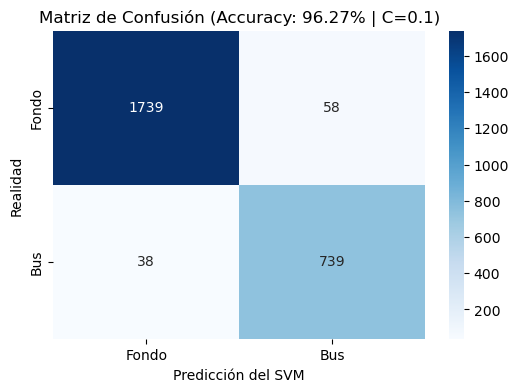

In [2]:
print("Cargando características HOG (X) y etiquetas (y)...")
X = np.load("X_features.npy")
y = np.load("y_labels.npy")

# Dividir datos: 80% para entrenar, 20% para examen final (validación)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Entrenando con {len(X_train)} imágenes, probando con {len(X_test)} imágenes.")
print(f"  - Train: {sum(y_train==1)} buses, {sum(y_train==0)} fondo")
print(f"  - Test:  {sum(y_test==1)} buses, {sum(y_test==0)} fondo\n")

print("[PROCESO] Iniciando Búsqueda del Mejor Parámetro C (Grid Search)...")
C_values = [0.001, 0.01, 0.1, 0.5, 1.0, 5.0, 10.0]

print(f"{'C':>8} | {'Accuracy':>10} | {'FP':>5} | {'FN':>5} | {'Bias(b)':>10} | {'Neg Score Avg':>14} | {'Pos Score Avg':>14}")
print("-" * 90)

best_c = None
best_score = 0

for C in C_values:
    model = LinearSVC(C=C, max_iter=10000, dual="auto")
    model.fit(X_train, y_train)
    
    y_pred_c = model.predict(X_test)
    acc_c = accuracy_score(y_test, y_pred_c)
    
    scores_test = X_test @ model.coef_[0] + model.intercept_[0]
    pos_mask = y_test == 1
    neg_mask = y_test == 0
    avg_pos = np.mean(scores_test[pos_mask])
    avg_neg = np.mean(scores_test[neg_mask])
    
    cm_c = confusion_matrix(y_test, y_pred_c)
    fp = cm_c[0][1]
    fn = cm_c[1][0]
    
    marker = " <-- MEJOR" if acc_c > best_score else ""
    print(f"{C:>8.3f} | {acc_c*100:>9.2f}% | {fp:>5} | {fn:>5} | {model.intercept_[0]:>10.4f} | {avg_neg:>14.4f} | {avg_pos:>14.4f}{marker}")
    
    if acc_c > best_score:
        best_score = acc_c
        best_c = C

print(f"\n[OK] Mejor C encontrado: {best_c} con accuracy = {best_score*100:.2f}%")
print(f"Entrenando el modelo final usando C={best_c}...")

# Instanciar el modelo SVM Lineal con el MEJOR C
svm_model = LinearSVC(C=best_c, max_iter=10000, dual="auto")
svm_model.fit(X_train, y_train)

# Examen final
y_pred = svm_model.predict(X_test)
acc = accuracy_score(y_test, y_pred)

print("\n[RESULTADOS] Reporte Detallado por Clase (Modelo V1):")
print(classification_report(y_test, y_pred, target_names=["Fondo (0)", "Bus Escolar (1)"]))

# Matriz de confusión
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Fondo","Bus"], yticklabels=["Fondo","Bus"])
plt.title(f"Matriz de Confusión (Accuracy: {acc*100:.2f}% | C={best_c})")
plt.xlabel("Predicción del SVM")
plt.ylabel("Realidad")
plt.show()

## Fase 4.1: True Hard Negative Mining
A diferencia del enfoque anterior (que buscaba errores en los recortes ya hechos), aquí armaremos un detector HOG en vivo. Lo pasaremos escaneando fotos gigantes enteras del fondo. Si el detector se equivoca y detecta una pared como bus, recortaremos esa pared exacta y se la inyectaremos al SVM para que aprenda su error.

In [3]:
print("Iniciando True Hard Negative Mining...")

# 1. Configurar el HOG de OpenCV con los pesos del Modelo V1
winSize = (128, 96)
hog_hnm = cv2.HOGDescriptor(winSize, (16,16), (8,8), (8,8), 9)

w = svm_model.coef_[0]
b = svm_model.intercept_[0]
hog_weights_v1 = np.append(w, b)
hog_hnm.setSVMDetector(hog_weights_v1)

clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
new_hard_negatives = []

# 2. Tomar una muestra de fotos gigantes de fondo (para no tardar demasiado)
neg_dir = "dataset/negatives"
all_neg_files = [os.path.join(neg_dir, f) for f in os.listdir(neg_dir) if f.endswith(('.jpg', '.png'))]

if len(all_neg_files) > 0:
    sample_size = min(800, len(all_neg_files))  # Escaneamos 800 imágenes gigantes de fondo
    sample_neg_files = random.sample(all_neg_files, sample_size)
    
    print(f"Escaneando {sample_size} imágenes completas de fondo en busca de errores...")
    
    for img_path in tqdm(sample_neg_files):
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        if img is None: continue
        img_clahe = clahe.apply(img)
        
        # Escanear la imagen completa buscando un falso bus
        # Ponemos hitThreshold=0.0 para ser exigentes y detectar cualquier mínima confusión
        rects, _ = hog_hnm.detectMultiScale(
            img_clahe, hitThreshold=0.0, winStride=(16, 16), padding=(16, 16), scale=1.15
        )
        
        # Si detectó algo en una imagen que sabemos que es puro fondo, ES UN ERROR
        for (x, y, w_box, h_box) in rects:
            crop = img_clahe[y:y+h_box, x:x+w_box]
            if crop.shape[0] > 0 and crop.shape[1] > 0:
                crop_resized = cv2.resize(crop, winSize)
                features = hog_hnm.compute(crop_resized)
                if features is not None:
                    new_hard_negatives.append(features.flatten())

    if len(new_hard_negatives) > 0:
        print(f"\n¡Se cazaron {len(new_hard_negatives)} nuevos recuadros engañosos (Falsos Positivos)!")
        new_hard_negatives = np.array(new_hard_negatives, dtype=np.float32)
        
        # Combinar estos errores crudos con el dataset de entrenamiento
        X_train_boosted = np.vstack([X_train, new_hard_negatives])
        y_train_boosted = np.concatenate([y_train, np.zeros(len(new_hard_negatives), dtype=np.int32)])
        
        print(f"\nRe-entrenando SVM (Modelo V2) con los {len(new_hard_negatives)} nuevos ejemplos forzados...")
        svm_model_v2 = LinearSVC(C=best_c, max_iter=10000, dual="auto")
        svm_model_v2.fit(X_train_boosted, y_train_boosted)
        
        y_pred_v2 = svm_model_v2.predict(X_test)
        acc_v2 = accuracy_score(y_test, y_pred_v2)
        
        # Calcular Falsos Positivos en el Test set para comparar
        cm_v1 = confusion_matrix(y_test, y_pred)
        cm_v2 = confusion_matrix(y_test, y_pred_v2)
        fp_v1 = cm_v1[0][1]
        fp_v2 = cm_v2[0][1]
        
        print(f"\nResultados del Reentrenamiento:")
        print(f"Accuracy ANTES (V1):  {acc*100:.2f}%")
        print(f"Accuracy DESPUÉS (V2): {acc_v2*100:.2f}%")
        print(f"Falsos Positivos en Validación: {fp_v1} -> {fp_v2}")
        
        # LÓGICA DE SEGURIDAD: Elegimos V2 si mejoró el Accuracy o si logró reducir los Falsos Positivos
        if acc_v2 >= acc or fp_v2 < fp_v1:
            print("\n[OK] El Modelo V2 es más robusto. Reemplazando Modelo V1 por el Modelo V2 blindado.")
            svm_model = svm_model_v2
        else:
            print("\n[ERROR] El Modelo V2 empeoró en ambas métricas. Mantenemos el Modelo V1 original por seguridad.")
            # No tocamos svm_model, se queda con V1
    else:
        print("\n[OK] El Modelo V1 es perfecto. No se encontró ni un solo falso positivo en las imágenes escaneadas.")
else:
    print("No se encontraron imágenes negativas para hacer el test.")


Iniciando True Hard Negative Mining...
Escaneando 800 imágenes completas de fondo en busca de errores...


100%|██████████| 800/800 [00:16<00:00, 49.22it/s]



¡Se cazaron 4259 nuevos recuadros engañosos (Falsos Positivos)!

Re-entrenando SVM (Modelo V2) con los 4259 nuevos ejemplos forzados...

Resultados del Reentrenamiento:
Accuracy ANTES (V1):  96.27%
Accuracy DESPUÉS (V2): 95.53%
Falsos Positivos en Validación: 58 -> 32

✅ El Modelo V2 es más robusto. Reemplazando Modelo V1 por el Modelo V2 blindado.


## Fase 4.2: Exportar Pesos (Cerebro) a C++
Guardamos los coeficientes del modelo ganador en un archivo `.txt` para que tu aplicación C++ pueda leerlos.

In [4]:
# Extraer coeficientes y bias del SVM ganador
w = svm_model.coef_[0]
b = svm_model.intercept_[0]

# OpenCV asume que la fórmula es (w * x) - rho, así que en teoría rho = -b.
# Pero si lo pasamos directo, el threshold de OpenCV se encarga del resto.
hog_weights = np.append(w, b)

weights_path = 'svm_hog_weights_128x96.txt'
np.savetxt(weights_path, hog_weights, fmt='%f')

print(f'[LISTO] ¡Cerebro exportado con éxito!')
print(f'Archivo guardado en: {weights_path}')
print(f'El archivo tiene {len(hog_weights)} pesos.')
print('[NOTA] Este es el archivo que tu programa C++ va a cargar en memoria.')

🎉 ¡Cerebro exportado con éxito!
Archivo guardado en: svm_hog_weights_128x96.txt
El archivo tiene 5941 pesos.
⚠️ Este es el archivo que tu programa C++ va a cargar en memoria.


## Fase 5: Pruebas Visuales en Video (Simulador)
Proba el detector exportado sobre tu video en Python antes de pasarte a C++.

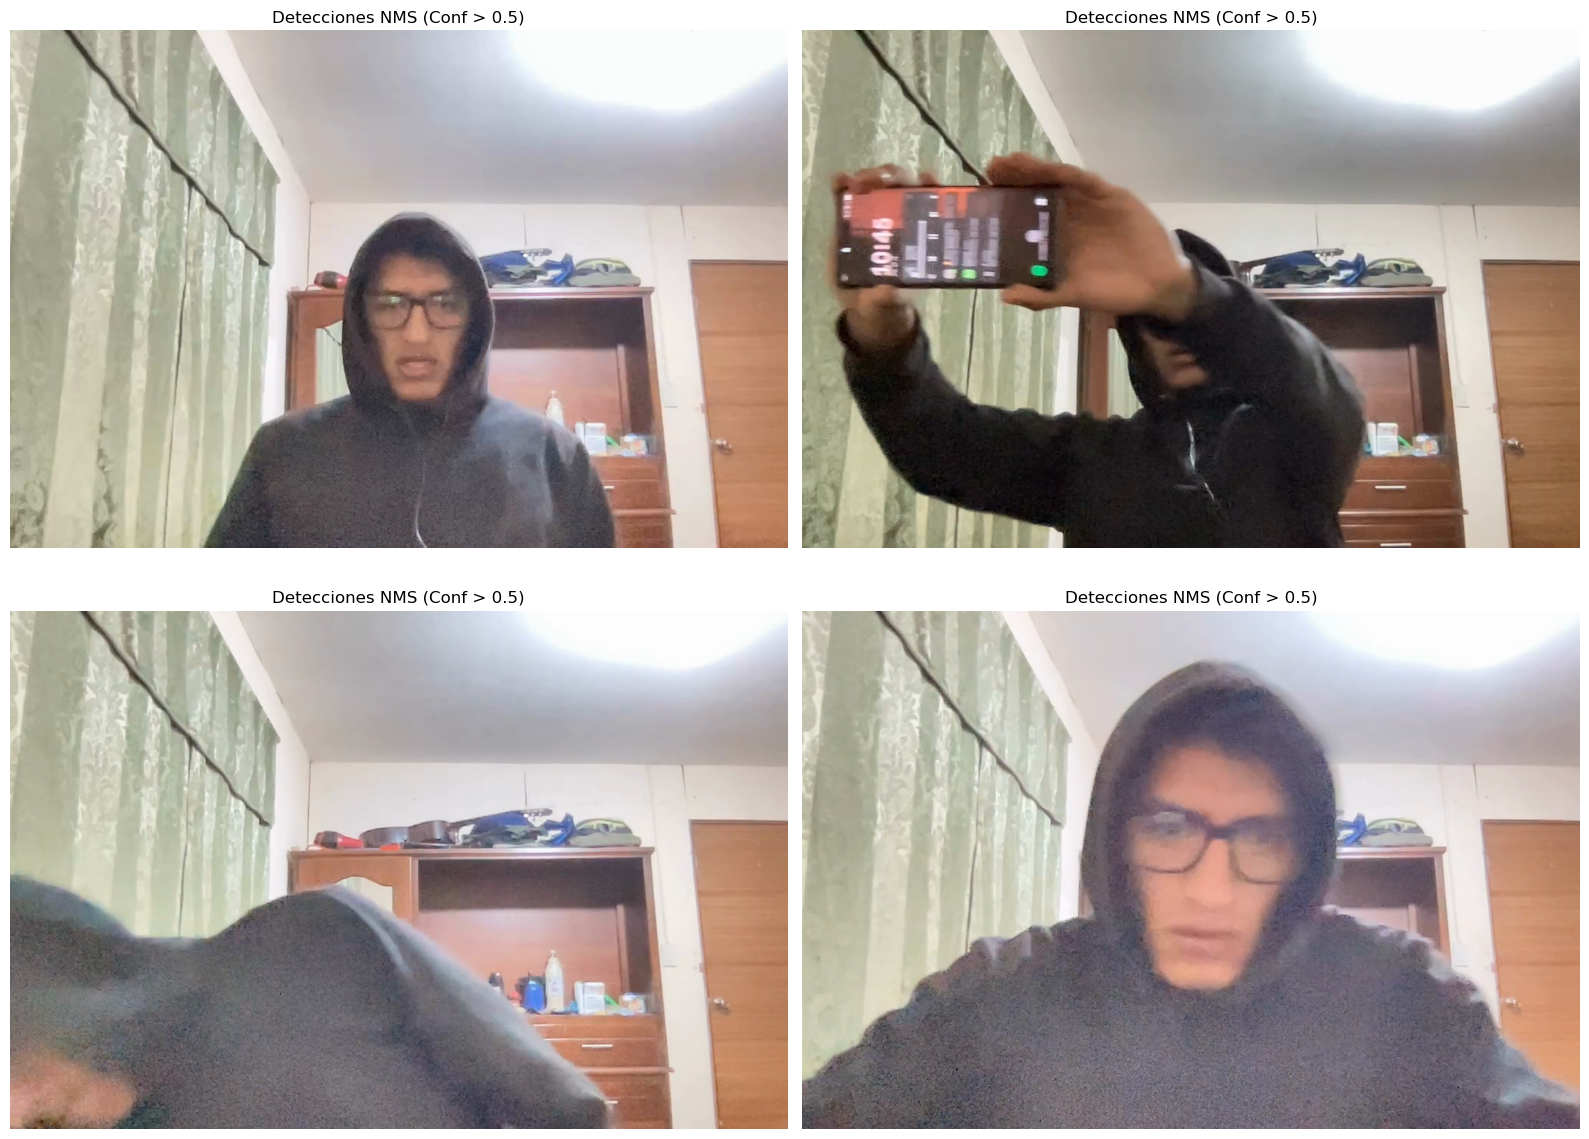

In [5]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

# --- CONFIGURACIÓN DE LA PRUEBA ---
TEST_MODE = "video"
TEST_PATH = "videos/video.mov"

hit_threshold = 1.5
win_stride = (16, 16)
padding = (16, 16)
scale = 1.15
nms_conf_thresh = 0.5

winSize = (128, 96)
hog_eval = cv2.HOGDescriptor(winSize, (16,16), (8,8), (8,8), 9)
hog_eval.setSVMDetector(hog_weights)
clahe_eval = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))

frames = []
if TEST_MODE == "video":
    cap = cv2.VideoCapture(TEST_PATH)
    if cap.isOpened():
        total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        for idx in np.linspace(0, max(0, total-2), 4):
            cap.set(cv2.CAP_PROP_POS_FRAMES, int(idx))
            ret, f = cap.read()
            if ret: frames.append(f)
        cap.release()

if len(frames) > 0:
    fig, axs = plt.subplots(2, 2, figsize=(16, 12))
    axs = axs.flatten()
    
    for i, frame in enumerate(frames):
        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        gray = clahe_eval.apply(gray)
        
        rects, weights_val = hog_eval.detectMultiScale(
            gray, hitThreshold=hit_threshold, winStride=win_stride, padding=padding, scale=scale
        )
        
        frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        if len(rects) > 0:
            r_arr = np.array(rects)
            w_arr = np.array(weights_val).flatten()
            mask = w_arr >= nms_conf_thresh
            r_arr, w_arr = r_arr[mask], w_arr[mask]
            
            if len(r_arr) > 0:
                indices = cv2.dnn.NMSBoxes(r_arr.tolist(), w_arr.tolist(), nms_conf_thresh, 0.3)
                if len(indices) > 0:
                    for idx in indices.flatten():
                        x, y, w_box, h_box = r_arr[idx]
                        conf = w_arr[idx]
                        cv2.rectangle(frame_rgb, (x, y), (x+w_box, y+h_box), (0, 255, 0), 3)
                        cv2.putText(frame_rgb, f"{conf:.2f}", (x, y-10), cv2.FONT_HERSHEY_SIMPLEX, 0.9, (0,255,0), 3)
                        
        axs[i].imshow(frame_rgb)
        axs[i].axis("off")
        axs[i].set_title(f"Detecciones NMS (Conf > {nms_conf_thresh})")

    plt.tight_layout()
    plt.show()